# Missense Variant Classification — dbNSFP via MyVariant.info API

**Objective:** Build a binary classifier (Pathogenic vs Benign) for missense variants using features from dbNSFP.

**Data Strategy:** Instead of downloading the full ~30 GB dbNSFP database, we query the **myvariant.info** REST API which serves all dbNSFP fields on demand. This way we only download data for our target genes — a few MB at most.

In [1]:
# ── Phase 1.1: Install Dependencies ──────────────────────────────────────────
# Run this cell once; restart the kernel afterwards if needed.
%pip install myvariant pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm imbalanced-learn tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ── Phase 1.2: Imports ───────────────────────────────────────────────────────
import warnings, os, json, time
warnings.filterwarnings("ignore")

import myvariant
import pandas as pd
import numpy as np
from tqdm import tqdm

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# ML (loaded later, imported early to catch missing packages)
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             matthews_corrcoef, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

print("All imports OK ✓")

All imports OK ✓


## Phase 1 — Configuration

### Target Genes
- **PAH** — Phenylalanine Hydroxylase (Phenylketonuria)
- **CFTR** — Cystic Fibrosis Transmembrane Conductance Regulator

### Genes associated with common hereditary diseases
We include well-characterised Mendelian disease genes from OMIM that have many ClinVar-reviewed missense variants.

In [3]:
# ── Phase 1.3: Target Genes & dbNSFP Fields ─────────────────────────────────

# Core target genes
TARGET_GENES = [
    # Primary
    "PAH",    # Phenylketonuria
    "CFTR",   # Cystic Fibrosis
    # Hereditary-disease genes with many ClinVar-reviewed missense variants
    "BRCA1",  # Hereditary Breast/Ovarian Cancer
    "BRCA2",  # Hereditary Breast/Ovarian Cancer
    "MLH1",   # Lynch Syndrome (Hereditary Colorectal Cancer)
    "MSH2",   # Lynch Syndrome
    "MSH6",   # Lynch Syndrome
    "TP53",   # Li-Fraumeni Syndrome
    "RB1",    # Retinoblastoma
    "SCN1A",  # Dravet Syndrome (Epilepsy)
    "HEXA",   # Tay-Sachs Disease
    "GBA",    # Gaucher Disease
    "GAA",    # Pompe Disease
    "HBB",    # Sickle Cell Disease / Beta-Thalassemia
    "LDLR",   # Familial Hypercholesterolemia
    "PKD1",   # Polycystic Kidney Disease
    "PKD2",   # Polycystic Kidney Disease
    "FBN1",   # Marfan Syndrome
    "TSC1",   # Tuberous Sclerosis
    "TSC2",   # Tuberous Sclerosis
    "MYH7",   # Hypertrophic Cardiomyopathy
    "MYBPC3", # Hypertrophic Cardiomyopathy
    "RET",    # Multiple Endocrine Neoplasia
    "VHL",    # Von Hippel-Lindau
    "ATM",    # Ataxia-Telangiectasia
]

print(f"Target genes: {len(TARGET_GENES)}")
print(TARGET_GENES)

# ── dbNSFP fields to retrieve via myvariant.info ────────────────────────────
# We request the complete dbnsfp + clinvar sub-documents.
# myvariant.info stores them under "dbnsfp" and "clinvar" keys.
FIELDS = [
    # dbNSFP core
    "dbnsfp.genename",
    "dbnsfp.aa",              # aa change info
    "dbnsfp.aaref",
    "dbnsfp.aaalt",
    "dbnsfp.aapos",
    "dbnsfp.hg38",            # chr / pos on GRCh38
    "dbnsfp.ref",
    "dbnsfp.alt",
    "dbnsfp.codonpos",
    # Conservation scores
    "dbnsfp.phylop100way_vertebrate",
    "dbnsfp.phylop30way_mammalian",
    "dbnsfp.phastcons100way_vertebrate",
    "dbnsfp.phastcons30way_mammalian",
    "dbnsfp.gerp++_rs",
    "dbnsfp.gerp++_nr",
    "dbnsfp.siphy_29way_logodds",
    # In silico prediction scores
    "dbnsfp.sift",
    "dbnsfp.polyphen2_hdiv",
    "dbnsfp.polyphen2_hvar",
    "dbnsfp.mutationtaster",
    "dbnsfp.mutationassessor",
    "dbnsfp.fathmm",
    "dbnsfp.provean",
    "dbnsfp.cadd",             # CADD raw + phred
    "dbnsfp.dann",
    "dbnsfp.revel",
    "dbnsfp.metalr",
    "dbnsfp.metasvm",
    # Population / allele frequency
    "dbnsfp.1000gp3",          # 1000 Genomes Phase 3 AF
    "dbnsfp.exac",
    "dbnsfp.gnomad_exomes",
    "dbnsfp.gnomad_genomes",
    "dbnsfp.esp6500",
    # Amino acid related
    "dbnsfp.ancestral_allele",
    # ClinVar annotations
    "clinvar.clinical_significance",
    "clinvar.review_status",
    "clinvar.hgvs",
    "clinvar.gene",
    "clinvar.rcv",
]

FIELDS_STR = ",".join(FIELDS)

# Initialise the myvariant.info client
mv = myvariant.MyVariantInfo()
print("MyVariant.info client initialised ✓")

Target genes: 25
['PAH', 'CFTR', 'BRCA1', 'BRCA2', 'MLH1', 'MSH2', 'MSH6', 'TP53', 'RB1', 'SCN1A', 'HEXA', 'GBA', 'GAA', 'HBB', 'LDLR', 'PKD1', 'PKD2', 'FBN1', 'TSC1', 'TSC2', 'MYH7', 'MYBPC3', 'RET', 'VHL', 'ATM']
MyVariant.info client initialised ✓


## Phase 1.4 — Data Acquisition from myvariant.info

For each target gene we query `dbnsfp.genename:<GENE>` and ask for only the fields we need.  
The API returns JSON documents — one per variant. We collect them all, then flatten into a DataFrame and save as CSV so subsequent runs can skip the download.

In [4]:
# ── Phase 1.4: Fetch variant data from myvariant.info ────────────────────────

CACHE_FILE = "dbnsfp_raw_variants.json"

if os.path.exists(CACHE_FILE):
    print(f"Loading cached data from {CACHE_FILE} ...")
    with open(CACHE_FILE, "r") as f:
        all_hits = json.load(f)
    print(f"Loaded {len(all_hits):,} variant records from cache.")
else:
    all_hits = []

    for gene in tqdm(TARGET_GENES, desc="Querying genes"):
        query = f"dbnsfp.genename:{gene}"
        try:
            results = mv.query(query, fields=FIELDS_STR, size=1000, fetch_all=True)
            hits = list(results)  # generator → list
            all_hits.extend(hits)
            print(f"  {gene}: {len(hits):,} variants")
        except Exception as e:
            print(f"  {gene}: ERROR — {e}")
        time.sleep(0.3)  # polite rate-limiting

    # Cache to disk
    with open(CACHE_FILE, "w") as f:
        json.dump(all_hits, f)
    print(f"\nTotal variants fetched: {len(all_hits):,}")
    print(f"Saved to {CACHE_FILE}")

Querying genes:   0%|          | 0/25 [00:00<?, ?it/s]Input sequence provided is already in string format. No operation performed
fetch_all implicitly disables HTTP request caching
No more results to return.


  PAH: 3,427 variants


Querying genes:   4%|▍         | 1/25 [00:06<02:42,  6.78s/it]Input sequence provided is already in string format. No operation performed
fetch_all implicitly disables HTTP request caching
No more results to return.


  CFTR: 10,768 variants


Querying genes:   8%|▊         | 2/25 [00:18<03:47,  9.88s/it]Input sequence provided is already in string format. No operation performed
fetch_all implicitly disables HTTP request caching
No more results to return.


...

  VHL: 1,484 variants


Querying genes:  96%|█████████▌| 24/25 [04:56<00:09,  9.27s/it]Input sequence provided is already in string format. No operation performed
fetch_all implicitly disables HTTP request caching
No more results to return.


  ATM: 22,530 variants


Querying genes: 100%|██████████| 25/25 [05:22<00:00, 12.90s/it]



Total variants fetched: 257,788
Saved to dbnsfp_raw_variants.json


In [5]:
# ── Phase 1.5: Flatten JSON → DataFrame ──────────────────────────────────────

df_raw = pd.json_normalize(all_hits, sep="_")
print(f"Raw DataFrame shape: {df_raw.shape}")
print(f"Columns ({len(df_raw.columns)}):")
for c in sorted(df_raw.columns):
    print(f"  {c}")
df_raw.head(3)

Raw DataFrame shape: (257788, 103)
Columns (103):
  _id
  _score
  clinvar__license
  clinvar_gene_id
  clinvar_gene_symbol
  clinvar_hgvs_coding
  clinvar_hgvs_genomic
  clinvar_hgvs_non-coding
  clinvar_hgvs_protein
  clinvar_rcv
  clinvar_rcv_accession
  clinvar_rcv_clinical_significance
  clinvar_rcv_conditions
  clinvar_rcv_conditions_identifiers_efo
  clinvar_rcv_conditions_identifiers_gene
  clinvar_rcv_conditions_identifiers_human_phenotype_ontology
  clinvar_rcv_conditions_identifiers_medgen
  clinvar_rcv_conditions_identifiers_mesh
  clinvar_rcv_conditions_identifiers_mondo
  clinvar_rcv_conditions_identifiers_omim
  clinvar_rcv_conditions_identifiers_orphanet
  clinvar_rcv_conditions_name
  clinvar_rcv_conditions_synonyms
  clinvar_rcv_last_evaluated
  clinvar_rcv_number_submitters
  clinvar_rcv_origin
  clinvar_rcv_preferred_name
  clinvar_rcv_review_status
  dbnsfp_1000gp3_ac
  dbnsfp_1000gp3_af
  dbnsfp_1000gp3_afr_ac
  dbnsfp_1000gp3_afr_af
  dbnsfp_1000gp3_amr_ac
  dbns

,_id,_score,dbnsfp__license,dbnsfp_aa_alt,dbnsfp_aa_codon_degeneracy,dbnsfp_aa_codonpos,dbnsfp_aa_pos,dbnsfp_aa_ref,dbnsfp_aa_refcodon,dbnsfp_alt,...,dbnsfp_1000gp3_eur_ac,dbnsfp_1000gp3_eur_af,dbnsfp_1000gp3_sas_ac,dbnsfp_1000gp3_sas_af,clinvar_rcv_conditions,dbnsfp_aa,clinvar_rcv_conditions_identifiers_human_phenotype_ontology,clinvar_hgvs_non-coding,clinvar_rcv_conditions_identifiers_gene,clinvar_rcv_conditions_identifiers_efo
0,chr12:g.103232973C>A,10.176809,http://bit.ly/2VLnQBz,S,"[0, 0]","[1, 1]","[447, 442]",A,"[GCC, GCC]",A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,chr12:g.103232976T>A,10.176809,http://bit.ly/2VLnQBz,C,"[0, 0]","[1, 1]","[446, 441]",S,"[AGT, AGT]",A,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chr12:g.103232979A>G,10.176809,http://bit.ly/2VLnQBz,R,"[0, 0]","[1, 1]","[445, 440]",C,"[TGC, TGC]",G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Phase 2 — Data Filtering & Cleaning

1. **SNV + missense only** — keep rows where `dbnsfp_aaref` and `dbnsfp_aaalt` are single amino acids (not `.`, `*`, or missing)
2. **ClinVar review status ≥ 3** — keep only expert-panel / practice-guideline reviewed variants
3. **Binary target** — map clinical significance to Benign (0) / Pathogenic (1); drop VUS
4. **Remove coordinate columns** after filtering

In [12]:
# ── Phase 2.1: Filter — keep only missense SNVs ─────────────────────────────

VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")  # 20 standard amino acids

def is_valid_aa(val):
    """Check if value is a single standard amino acid letter."""
    if isinstance(val, list):
        # some variants have multiple transcripts; take the first
        val = val[0] if len(val) > 0 else None
    return isinstance(val, str) and len(val) == 1 and val.upper() in VALID_AA

# Handle list-typed columns — take the first element
for col in ["dbnsfp_aa_ref", "dbnsfp_aa_alt"]:
    if col in df_raw.columns:
        df_raw[col] = df_raw[col].apply(
            lambda x: x[0] if isinstance(x, list) and len(x) > 0 else x
        )

df = df_raw.copy()
before = len(df)

# Keep only rows with valid aaref and aaalt (= missense SNVs)
mask_missense = (
    df["dbnsfp_aa_ref"].apply(lambda x: isinstance(x, str) and len(x) == 1 and x.upper() in VALID_AA) &
    df["dbnsfp_aa_alt"].apply(lambda x: isinstance(x, str) and len(x) == 1 and x.upper() in VALID_AA) &
    (df["dbnsfp_aa_ref"] != df["dbnsfp_aa_alt"])  # exclude synonymous
)
df = df[mask_missense].reset_index(drop=True)

print(f"Missense SNV filter: {before:,} → {len(df):,}  (dropped {before - len(df):,})")

Missense SNV filter: 257,788 → 235,121  (dropped 22,667)


In [13]:
# ── Phase 2.2: Parse ClinVar review status & filter >= 1 star ────────────────

# myvariant.info returns review_status as a string like:reviewed by expert panel
# or as a list. Map known strings to numeric star ratings.

REVIEW_STAR_MAP = {
    "no_assertion_criteria_provided": 0,
    "no assertion criteria provided": 0,
    "criteria_provided,_single_submitter": 1,
    "criteria provided, single submitter": 1,
    "criteria_provided,_conflicting_interpretations": 1,
    "criteria provided, conflicting interpretations": 1,
    "criteria_provided,_multiple_submitters,_no_conflicts": 2,
    "criteria provided, multiple submitters, no conflicts": 2,
    "reviewed_by_expert_panel": 3,
    "reviewed by expert panel": 3,
    "practice_guideline": 4,
    "practice guideline": 4,
}

def parse_review_stars(val):
    """Convert ClinVar review_status string(s) to the highest star rating."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return -1
    if isinstance(val, list):
        return max(parse_review_stars(v) for v in val)
    val_lower = str(val).strip().lower()
    return REVIEW_STAR_MAP.get(val_lower, -1)

df["review_stars"] = df["clinvar_rcv_review_status"].apply(parse_review_stars)
print("Review star distribution:")
print(df["review_stars"].value_counts().sort_index())

before = len(df)
df = df[df["review_stars"] >= 1].reset_index(drop=True)
print(f"\nReview status filter (>= 1 star): {before:,} → {len(df):,}  (dropped {before - len(df):,})")

Review star distribution:
review_stars
-1    204773
 0      1024
 1     28099
 2       904
 3       321
Name: count, dtype: int64

Review status filter (>= 1 star): 235,121 → 29,324  (dropped 205,797)


In [14]:
# ── Phase 2.3: Define binary target variable ─────────────────────────────────

def map_significance(val):
    """Map ClinVar clinical_significance to binary label (0=Benign, 1=Pathogenic, -1=drop)."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return -1
    if isinstance(val, list):
        val = val[0]
    val_lower = str(val).strip().lower()

    benign_terms = {"benign", "likely benign", "benign/likely benign",
                    "likely_benign", "benign/likely_benign"}
    pathogenic_terms = {"pathogenic", "likely pathogenic", "pathogenic/likely pathogenic",
                        "likely_pathogenic", "pathogenic/likely_pathogenic"}

    if val_lower in benign_terms:
        return 0
    elif val_lower in pathogenic_terms:
        return 1
    else:
        return -1  # VUS, conflicting, etc.

df["label"] = df["clinvar_rcv_clinical_significance"].apply(map_significance)

print("Label distribution BEFORE dropping unknowns:")
print(df["label"].value_counts().sort_index())

before = len(df)
df = df[df["label"] >= 0].reset_index(drop=True)
print(f"\nDropped VUS / other: {before:,} → {len(df):,}")

print("\nFinal label distribution:")
print(df["label"].value_counts().rename({0: "Benign", 1: "Pathogenic"}))

Label distribution BEFORE dropping unknowns:
label
-1    25460
 0     1100
 1     2764
Name: count, dtype: int64

Dropped VUS / other: 29,324 → 3,864

Final label distribution:
label
Pathogenic    2764
Benign        1100
Name: count, dtype: int64


## Phase 3 — Feature Engineering

### 3.1 Biochemical & Structural Delta Features
Custom-engineered from amino acid physicochemical property lookup tables.
- Δ Hydrophobicity, Δ Volume, Δ Charge, Δ Molecular Weight, Δ Polarity
- Grantham distance (1974)

In [15]:
# ── Phase 3.1: Amino Acid Property Tables & Biochemical Delta Features ───────

# Kyte-Doolittle hydropathy index
HYDROPHOBICITY = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8,
    'G': -0.4, 'H': -3.2, 'I': 4.5, 'K': -3.9, 'L': 3.8,
    'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5,
    'S': -0.8, 'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3,
}

# Zamyatnin residue volume (Å³)
VOLUME = {
    'A': 88.6, 'C': 108.5, 'D': 111.1, 'E': 138.4, 'F': 189.9,
    'G': 60.1, 'H': 153.2, 'I': 166.7, 'K': 168.6, 'L': 166.7,
    'M': 162.9, 'N': 114.1, 'P': 112.7, 'Q': 143.8, 'R': 173.4,
    'S': 89.0, 'T': 116.1, 'V': 140.0, 'W': 227.8, 'Y': 193.6,
}

# Charge at pH 7
CHARGE = {
    'A': 0, 'C': 0, 'D': -1, 'E': -1, 'F': 0,
    'G': 0, 'H': 0.1, 'I': 0, 'K': 1, 'L': 0,
    'M': 0, 'N': 0, 'P': 0, 'Q': 0, 'R': 1,
    'S': 0, 'T': 0, 'V': 0, 'W': 0, 'Y': 0,
}

# Molecular weight (Da)
MOL_WEIGHT = {
    'A': 89.1, 'C': 121.2, 'D': 133.1, 'E': 147.1, 'F': 165.2,
    'G': 75.0, 'H': 155.2, 'I': 131.2, 'K': 146.2, 'L': 131.2,
    'M': 149.2, 'N': 132.1, 'P': 115.1, 'Q': 146.2, 'R': 174.2,
    'S': 105.1, 'T': 119.1, 'V': 117.1, 'W': 204.2, 'Y': 181.2,
}

# Zimmerman polarity index
POLARITY = {
    'A': 0.0, 'C': 1.48, 'D': 49.7, 'E': 49.9, 'F': 0.35,
    'G': 0.0, 'H': 51.6, 'I': 0.13, 'K': 49.5, 'L': 0.13,
    'M': 1.43, 'N': 3.38, 'P': 1.58, 'Q': 3.53, 'R': 52.0,
    'S': 1.67, 'T': 1.66, 'V': 0.13, 'W': 2.10, 'Y': 1.61,
}

# Grantham distance components (composition c, polarity p, volume v)
GRANTHAM_C = {
    'A': 0.0, 'C': 2.75, 'D': 1.38, 'E': 0.92, 'F': 0.0,
    'G': 0.74, 'H': 0.58, 'I': 0.0, 'K': 0.33, 'L': 0.0,
    'M': 0.0, 'N': 1.33, 'P': 0.39, 'Q': 0.89, 'R': 0.65,
    'S': 1.42, 'T': 0.71, 'V': 0.0, 'W': 0.13, 'Y': 0.20,
}
GRANTHAM_P = {
    'A': 8.1, 'C': 5.5, 'D': 13.0, 'E': 12.3, 'F': 5.2,
    'G': 9.0, 'H': 10.4, 'I': 5.2, 'K': 11.3, 'L': 4.9,
    'M': 5.7, 'N': 11.6, 'P': 8.0, 'Q': 10.5, 'R': 10.5,
    'S': 9.2, 'T': 8.6, 'V': 5.9, 'W': 5.4, 'Y': 6.2,
}
GRANTHAM_V = {
    'A': 31.0, 'C': 55.0, 'D': 54.0, 'E': 83.0, 'F': 132.0,
    'G': 3.0, 'H': 96.0, 'I': 111.0, 'K': 119.0, 'L': 111.0,
    'M': 105.0, 'N': 56.0, 'P': 32.5, 'Q': 85.0, 'R': 124.0,
    'S': 32.0, 'T': 61.0, 'V': 84.0, 'W': 170.0, 'Y': 136.0,
}

# Grantham distance weights (from original 1974 paper)
ALPHA = 1.833
BETA = 0.1018
GAMMA = 0.000399

def grantham_distance(aa1, aa2):
    """Calculate Grantham distance between two amino acids."""
    if aa1 == aa2:
        return 0.0
    dc = abs(GRANTHAM_C.get(aa1, 0) - GRANTHAM_C.get(aa2, 0))
    dp = abs(GRANTHAM_P.get(aa1, 0) - GRANTHAM_P.get(aa2, 0))
    dv = abs(GRANTHAM_V.get(aa1, 0) - GRANTHAM_V.get(aa2, 0))
    return np.sqrt(ALPHA * dc**2 + BETA * dp**2 + GAMMA * dv**2)

# Compute delta features
df["delta_hydrophobicity"] = df.apply(
    lambda r: HYDROPHOBICITY.get(r["dbnsfp_aa_alt"], 0) - HYDROPHOBICITY.get(r["dbnsfp_aa_ref"], 0), axis=1)
df["delta_volume"] = df.apply(
    lambda r: VOLUME.get(r["dbnsfp_aa_alt"], 0) - VOLUME.get(r["dbnsfp_aa_ref"], 0), axis=1)
df["delta_charge"] = df.apply(
    lambda r: CHARGE.get(r["dbnsfp_aa_alt"], 0) - CHARGE.get(r["dbnsfp_aa_ref"], 0), axis=1)
df["delta_mol_weight"] = df.apply(
    lambda r: MOL_WEIGHT.get(r["dbnsfp_aa_alt"], 0) - MOL_WEIGHT.get(r["dbnsfp_aa_ref"], 0), axis=1)
df["delta_polarity"] = df.apply(
    lambda r: POLARITY.get(r["dbnsfp_aa_alt"], 0) - POLARITY.get(r["dbnsfp_aa_ref"], 0), axis=1)
df["grantham_distance"] = df.apply(
    lambda r: grantham_distance(r["dbnsfp_aa_ref"], r["dbnsfp_aa_alt"]), axis=1)

print("Biochemical delta features added ✓")
df[["dbnsfp_aa_ref", "dbnsfp_aa_alt",
    "delta_hydrophobicity", "delta_volume", "delta_charge",
    "delta_mol_weight", "delta_polarity", "grantham_distance"]].head(10)

Biochemical delta features added ✓


,dbnsfp_aa_ref,dbnsfp_aa_alt,delta_hydrophobicity,delta_volume,delta_charge,delta_mol_weight,delta_polarity,grantham_distance
0,L,P,-5.4,-54.0,0.0,-16.1,1.45,1.927650
1,R,L,8.3,-6.7,-1.0,-43.0,-51.87,2.008562
2,H,P,1.6,-40.5,-0.1,-40.1,-50.02,1.503798
3,F,L,1.0,-23.2,0.0,-34.0,-0.22,0.430257
4,T,N,-2.8,-2.0,0.0,13.0,1.72,1.277020
5,V,A,-2.4,-51.4,0.0,-28.0,-0.13,1.270237
6,L,M,-1.9,-3.8,0.0,18.0,1.30,0.281986
7,A,V,2.4,51.4,0.0,28.0,0.13,1.270237
8,P,T,0.9,3.4,0.0,4.0,0.08,0.740564
9,S,C,3.3,19.5,0.0,16.1,-0.19,2.201615


### 3.2 Amino Acid Encoding & Change Info
Encode the reference/alternate amino acids as physicochemical property vectors (more informative than plain one-hot).  
Also extract amino acid position and codon position from dbNSFP.

In [16]:
# ── Phase 3.2: Amino Acid Encoding & Change Info ─────────────────────────────

# Physicochemical property vectors for ref and alt amino acids
# Each AA is represented by (hydrophobicity, volume, charge, mol_weight, polarity)
def aa_property_vector(aa, prefix):
    """Return a dict of physicochemical properties for a single amino acid."""
    return {
        f"{prefix}_hydrophobicity": HYDROPHOBICITY.get(aa, np.nan),
        f"{prefix}_volume": VOLUME.get(aa, np.nan),
        f"{prefix}_charge": CHARGE.get(aa, np.nan),
        f"{prefix}_mol_weight": MOL_WEIGHT.get(aa, np.nan),
        f"{prefix}_polarity": POLARITY.get(aa, np.nan),
    }

# Encode ref and alt amino acid properties
ref_props = df["dbnsfp_aa_ref"].apply(lambda aa: pd.Series(aa_property_vector(aa, "ref")))
alt_props = df["dbnsfp_aa_alt"].apply(lambda aa: pd.Series(aa_property_vector(aa, "alt")))
df = pd.concat([df, ref_props, alt_props], axis=1)

# Extract amino acid position (numeric)
def safe_first_numeric(val):
    """Extract first numeric value from potentially nested/list values."""
    if isinstance(val, list):
        val = val[0] if len(val) > 0 else None
    try:
        return float(val)
    except (TypeError, ValueError):
        return np.nan

df["aa_position"] = df.get("dbnsfp_aa_pos", pd.Series([np.nan]*len(df))).apply(safe_first_numeric)

# Codon position (1, 2, or 3 — position within the triplet)
df["codon_position"] = df.get("dbnsfp_aa_codonpos", pd.Series([np.nan]*len(df))).apply(safe_first_numeric)

print("AA encoding & change info features added ✓")
print(f"  ref/alt property vectors: 10 features")
print(f"  aa_position, codon_position: 2 features")
df[["dbnsfp_aa_ref", "dbnsfp_aa_alt", "ref_hydrophobicity", "alt_hydrophobicity",
    "aa_position", "codon_position"]].head(5)

AA encoding & change info features added ✓
  ref/alt property vectors: 10 features
  aa_position, codon_position: 2 features


,dbnsfp_aa_ref,dbnsfp_aa_alt,ref_hydrophobicity,alt_hydrophobicity,aa_position,codon_position
0,L,P,3.8,-1.6,348.0,2.0
1,R,L,-4.5,3.8,261.0,2.0
2,H,P,-3.2,-1.6,220.0,2.0
3,F,L,2.8,3.8,382.0,3.0
4,T,N,-0.7,-3.5,81.0,2.0


### 3.3 Evolutionary Conservation Scores
Extracted directly from dbNSFP columns. These measure how conserved a genomic position is across species — highly conserved positions are more likely to be functionally important.

In [17]:
# ── Phase 3.3: Extract Conservation Scores ───────────────────────────────────

# Map actual column names from df_raw to clean feature names.
# The API returned dbnsfp_gerp_91_mammals_* instead of phyloP/phastCons/GERP++/SiPhy.
CONSERVATION_COLS_MAP = {
    # GERP (actual columns from myvariant.info)
    "dbnsfp_gerp_91_mammals_score":     "gerp_91_mammals_score",
    "dbnsfp_gerp_91_mammals_rankscore": "gerp_91_mammals_rankscore",
    # Also try common naming variants in case they appear in future queries
    "dbnsfp_phylop100way_vertebrate":   "phylop100way_vertebrate",
    "dbnsfp_phylop30way_mammalian":     "phylop30way_mammalian",
    "dbnsfp_phastcons100way_vertebrate":"phastcons100way_vertebrate",
    "dbnsfp_phastcons30way_mammalian":  "phastcons30way_mammalian",
    "dbnsfp_gerp++_rs":                 "gerp_rs",
    "dbnsfp_gerp++_nr":                 "gerp_nr",
    "dbnsfp_siphy_29way_logodds":       "siphy_29way_logodds",
}

conservation_found = []
for raw_col, clean_name in CONSERVATION_COLS_MAP.items():
    if raw_col in df.columns and clean_name not in df.columns:
        df[clean_name] = df[raw_col].apply(safe_first_numeric)
        conservation_found.append(clean_name)

# Deduplicate in case both naming variants matched
conservation_found = list(dict.fromkeys(conservation_found))
print(f"Conservation features extracted: {len(conservation_found)}")
for c in conservation_found:
    non_null = df[c].notna().sum()
    print(f"  {c}: {non_null:,} non-null ({non_null/len(df)*100:.1f}%)")

Conservation features extracted: 2
  gerp_91_mammals_score: 2,455 non-null (63.5%)
  gerp_91_mammals_rankscore: 2,455 non-null (63.5%)


### 3.4 Population / Minor Allele Frequency (MAF)
Allele frequencies from population databases (gnomAD, 1000 Genomes, ExAC, ESP). Rare variants are more likely pathogenic; common variants are more likely benign.

In [18]:
# ── Phase 3.4: Population / Minor Allele Frequency ──────────────────────────

# Map actual column names to clean feature names
MAF_COLS_MAP = {
    # 1000 Genomes
    "dbnsfp_1000gp3_af":                 "thousand_genomes_af",
    "dbnsfp_1000gp3_ac":                 "thousand_genomes_ac",
    # ExAC
    "dbnsfp_exac_af":                    "exac_af",
    "dbnsfp_exac_ac":                    "exac_ac",
    "dbnsfp_exac_adj_af":               "exac_adj_af",
    # ESP
    "dbnsfp_esp6500_aa_af":              "esp6500_aa_af",
    "dbnsfp_esp6500_ea_af":              "esp6500_ea_af",
    # gnomAD (may not be present but include for robustness)
    "dbnsfp_gnomad_exomes_af":           "gnomad_exomes_af",
    "dbnsfp_gnomad_genomes_af":          "gnomad_genomes_af",
}

maf_found = []
for raw_col, clean_name in MAF_COLS_MAP.items():
    if raw_col in df.columns and clean_name not in df.columns:
        df[clean_name] = df[raw_col].apply(safe_first_numeric)
        maf_found.append(clean_name)

maf_found = list(dict.fromkeys(maf_found))

# Create a combined max_af feature (highest frequency across databases)
af_cols_available = [c for c in ["gnomad_exomes_af", "gnomad_genomes_af",
                                  "thousand_genomes_af", "exac_af",
                                  "esp6500_aa_af", "esp6500_ea_af"] if c in df.columns]
if af_cols_available:
    df["max_population_af"] = df[af_cols_available].max(axis=1)
    maf_found.append("max_population_af")

    # Binary: is the variant rare (AF < 0.01)?
    df["is_rare"] = (df["max_population_af"].fillna(0) < 0.01).astype(int)
    maf_found.append("is_rare")

print(f"MAF features extracted: {len(maf_found)}")
for c in maf_found:
    non_null = df[c].notna().sum()
    print(f"  {c}: {non_null:,} non-null ({non_null/len(df)*100:.1f}%)")

MAF features extracted: 9
  thousand_genomes_af: 46 non-null (1.2%)
  thousand_genomes_ac: 46 non-null (1.2%)
  exac_af: 243 non-null (6.3%)
  exac_ac: 243 non-null (6.3%)
  exac_adj_af: 243 non-null (6.3%)
  esp6500_aa_af: 22 non-null (0.6%)
  esp6500_ea_af: 22 non-null (0.6%)
  max_population_af: 256 non-null (6.6%)
  is_rare: 3,864 non-null (100.0%)


### 3.5 In Silico Prediction / Risk Scores
Computational scores that predict variant deleteriousness. Extracted directly from the dbNSFP fields returned by myvariant.info.

In [19]:
# ── Phase 3.5: In Silico Prediction / Risk Scores ────────────────────────────

# Map actual column names to clean feature names
SCORE_COLS_MAP = {
    "dbnsfp_sift_score":                       "sift_score",
    "dbnsfp_sift_converted_rankscore":         "sift_rankscore",
    "dbnsfp_fathmm_score":                     "fathmm_score",
    "dbnsfp_fathmm_converted_rankscore":       "fathmm_rankscore",
    "dbnsfp_provean_score":                    "provean_score",
    "dbnsfp_provean_converted_rankscore":      "provean_rankscore",
    "dbnsfp_mutationtaster_score":             "mutationtaster_score",
    "dbnsfp_mutationtaster_converted_rankscore": "mutationtaster_rankscore",
    "dbnsfp_mutationassessor_score":           "mutationassessor_score",
    "dbnsfp_mutationassessor_rankscore":       "mutationassessor_rankscore",
    "dbnsfp_dann_score":                       "dann_score",
    "dbnsfp_dann_rankscore":                   "dann_rankscore",
    "dbnsfp_revel_score":                      "revel_score",
    "dbnsfp_revel_rankscore":                  "revel_rankscore",
    "dbnsfp_metalr_score":                     "metalr_score",
    "dbnsfp_metalr_rankscore":                 "metalr_rankscore",
    "dbnsfp_metasvm_score":                    "metasvm_score",
    "dbnsfp_metasvm_rankscore":                "metasvm_rankscore",
    # These may not be present in current data but include for robustness
    "dbnsfp_polyphen2_hdiv_score":             "polyphen2_hdiv_score",
    "dbnsfp_polyphen2_hvar_score":             "polyphen2_hvar_score",
    "dbnsfp_cadd_phred":                       "cadd_phred",
    "dbnsfp_cadd_raw":                         "cadd_raw",
}

scores_found = []
for raw_col, clean_name in SCORE_COLS_MAP.items():
    if raw_col in df.columns and clean_name not in df.columns:
        df[clean_name] = df[raw_col].apply(safe_first_numeric)
        scores_found.append(clean_name)

scores_found = list(dict.fromkeys(scores_found))
print(f"In silico score features extracted: {len(scores_found)}")
for c in scores_found:
    non_null = df[c].notna().sum()
    print(f"  {c}: {non_null:,} non-null ({non_null/len(df)*100:.1f}%)")

In silico score features extracted: 18
  sift_score: 3,734 non-null (96.6%)
  sift_rankscore: 3,734 non-null (96.6%)
  fathmm_score: 3,753 non-null (97.1%)
  fathmm_rankscore: 3,753 non-null (97.1%)
  provean_score: 3,751 non-null (97.1%)
  provean_rankscore: 3,751 non-null (97.1%)
  mutationtaster_score: 3,864 non-null (100.0%)
  mutationtaster_rankscore: 3,864 non-null (100.0%)
  mutationassessor_score: 2,749 non-null (71.1%)
  mutationassessor_rankscore: 2,749 non-null (71.1%)
  dann_score: 3,864 non-null (100.0%)
  dann_rankscore: 3,864 non-null (100.0%)
  revel_score: 3,723 non-null (96.4%)
  revel_rankscore: 3,723 non-null (96.4%)
  metalr_score: 3,765 non-null (97.4%)
  metalr_rankscore: 3,765 non-null (97.4%)
  metasvm_score: 3,765 non-null (97.4%)
  metasvm_rankscore: 3,765 non-null (97.4%)


### 3.6 Remove Genomic Coordinate Columns & Build Final Feature Matrix
**Critical requirement:** Drop all chr/pos/coordinate columns so the model never sees genomic location.

In [20]:
# ── Phase 3.6: Remove Coordinate Columns & Build Feature Matrix ──────────────

# Identify all coordinate / ID / meta columns to drop
DROP_PATTERNS = [
    "_id", "chr", "pos", "hg38", "hg19", "hg18",
    "genename", "ensembl", "uniprot", "refseq",
    "clinvar_", "review_stars", "label",                # target & ClinVar meta
    "aaref", "aaalt", "ref", "alt", "ancestral_allele", # raw AA/allele strings
    "clinvar", "rcv",
]

# Collect columns to drop
cols_to_drop = set()
for col in df.columns:
    col_lower = col.lower()
    for pattern in DROP_PATTERNS:
        if pattern in col_lower:
            cols_to_drop.add(col)
            break

# Always keep the engineered features and label
KEEP_ALWAYS = {"label"}
cols_to_drop -= KEEP_ALWAYS

print(f"Dropping {len(cols_to_drop)} non-feature columns:")
for c in sorted(cols_to_drop):
    print(f"  ❌ {c}")

# Build clean feature DataFrame
feature_cols = [c for c in df.columns if c not in cols_to_drop and c != "label"]

# Keep only numeric feature columns
df_features = df[feature_cols].copy()
non_numeric = df_features.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"\nDropping {len(non_numeric)} non-numeric columns: {non_numeric}")
    df_features = df_features.drop(columns=non_numeric)

feature_cols = df_features.columns.tolist()

print(f"\n✅ Final feature matrix: {df_features.shape[0]:,} samples × {len(feature_cols)} features")
print("\nFeature list:")
for i, c in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {c}")

Dropping 51 non-feature columns:
  ❌ _id
  ❌ aa_position
  ❌ alt_charge
  ❌ alt_hydrophobicity
  ❌ alt_mol_weight
  ❌ alt_polarity
  ❌ alt_volume
  ❌ clinvar__license
  ❌ clinvar_gene_id
  ❌ clinvar_gene_symbol
  ❌ clinvar_hgvs_coding
  ❌ clinvar_hgvs_genomic
  ❌ clinvar_hgvs_non-coding
  ❌ clinvar_hgvs_protein
  ❌ clinvar_rcv
  ❌ clinvar_rcv_accession
  ❌ clinvar_rcv_clinical_significance
  ❌ clinvar_rcv_conditions
  ❌ clinvar_rcv_conditions_identifiers_efo
  ❌ clinvar_rcv_conditions_identifiers_gene
  ❌ clinvar_rcv_conditions_identifiers_human_phenotype_ontology
  ❌ clinvar_rcv_conditions_identifiers_medgen
  ❌ clinvar_rcv_conditions_identifiers_mesh
  ❌ clinvar_rcv_conditions_identifiers_mondo
  ❌ clinvar_rcv_conditions_identifiers_omim
  ❌ clinvar_rcv_conditions_identifiers_orphanet
  ❌ clinvar_rcv_conditions_name
  ❌ clinvar_rcv_conditions_synonyms
  ❌ clinvar_rcv_last_evaluated
  ❌ clinvar_rcv_number_submitters
  ❌ clinvar_rcv_origin
  ❌ clinvar_rcv_preferred_name
  ❌ clinvar_rcv

In [21]:
# ── Phase 3.7: Handle Missing Values ─────────────────────────────────────────

# Show missingness summary
missing_pct = df_features.isnull().mean().sort_values(ascending=False) * 100
print("Missing value % per feature:")
print(missing_pct.to_string())

# Drop features with > 80% missing
high_missing = missing_pct[missing_pct > 80].index.tolist()
if high_missing:
    print(f"\n⚠️  Dropping {len(high_missing)} features with >80% missing: {high_missing}")
    df_features = df_features.drop(columns=high_missing)
    feature_cols = df_features.columns.tolist()

# Impute remaining missing values with column median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(df_features),
    columns=df_features.columns,
    index=df_features.index,
)

y = df["label"].values

print(f"\n✅ After imputation: {X_imputed.shape[0]:,} samples × {X_imputed.shape[1]} features, 0 missing")
print(f"   Label distribution: Benign={sum(y==0):,}  Pathogenic={sum(y==1):,}")

Missing value % per feature:
dbnsfp_esp6500_aa_ac                         99.430642
dbnsfp_esp6500_ea_ac                         99.430642
dbnsfp_esp6500_ea_af                         99.430642
dbnsfp_esp6500_aa_af                         99.430642
esp6500_aa_af                                99.430642
esp6500_ea_af                                99.430642
dbnsfp_1000gp3_sas_af                        98.809524
dbnsfp_1000gp3_eur_ac                        98.809524
dbnsfp_1000gp3_amr_af                        98.809524
dbnsfp_1000gp3_eas_ac                        98.809524
dbnsfp_1000gp3_eur_af                        98.809524
dbnsfp_1000gp3_sas_ac                        98.809524
dbnsfp_1000gp3_af                            98.809524
dbnsfp_1000gp3_afr_ac                        98.809524
dbnsfp_1000gp3_afr_af                        98.809524
dbnsfp_1000gp3_amr_ac                        98.809524
thousand_genomes_ac                          98.809524
thousand_genomes_af                 

---
## Phase 4 — Exploratory Data Analysis (EDA)

### 4.1 Class Distribution
### 4.2 Feature Distributions (key features, grouped by class)
### 4.3 Correlation Heatmap
### 4.4 Missing Value Summary (pre-imputation snapshot)

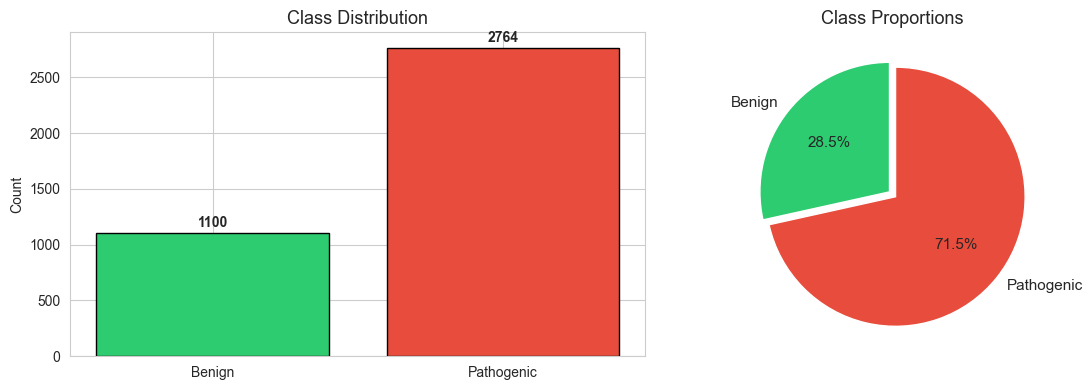

Imbalance ratio: 2.51:1


In [22]:
# ── Phase 4.1: Class Distribution ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts = pd.Series(y).value_counts().sort_index()
class_labels = ["Benign", "Pathogenic"]
colors = ["#2ecc71", "#e74c3c"]
axes[0].bar(class_labels, class_counts.values, color=colors, edgecolor="black")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + max(class_counts)*0.02, str(v), ha="center", fontweight="bold")
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(class_counts.values, labels=class_labels, colors=colors,
            autopct="%1.1f%%", startangle=90, explode=(0.03, 0.03),
            textprops={"fontsize": 11})
axes[1].set_title("Class Proportions", fontsize=13)

plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

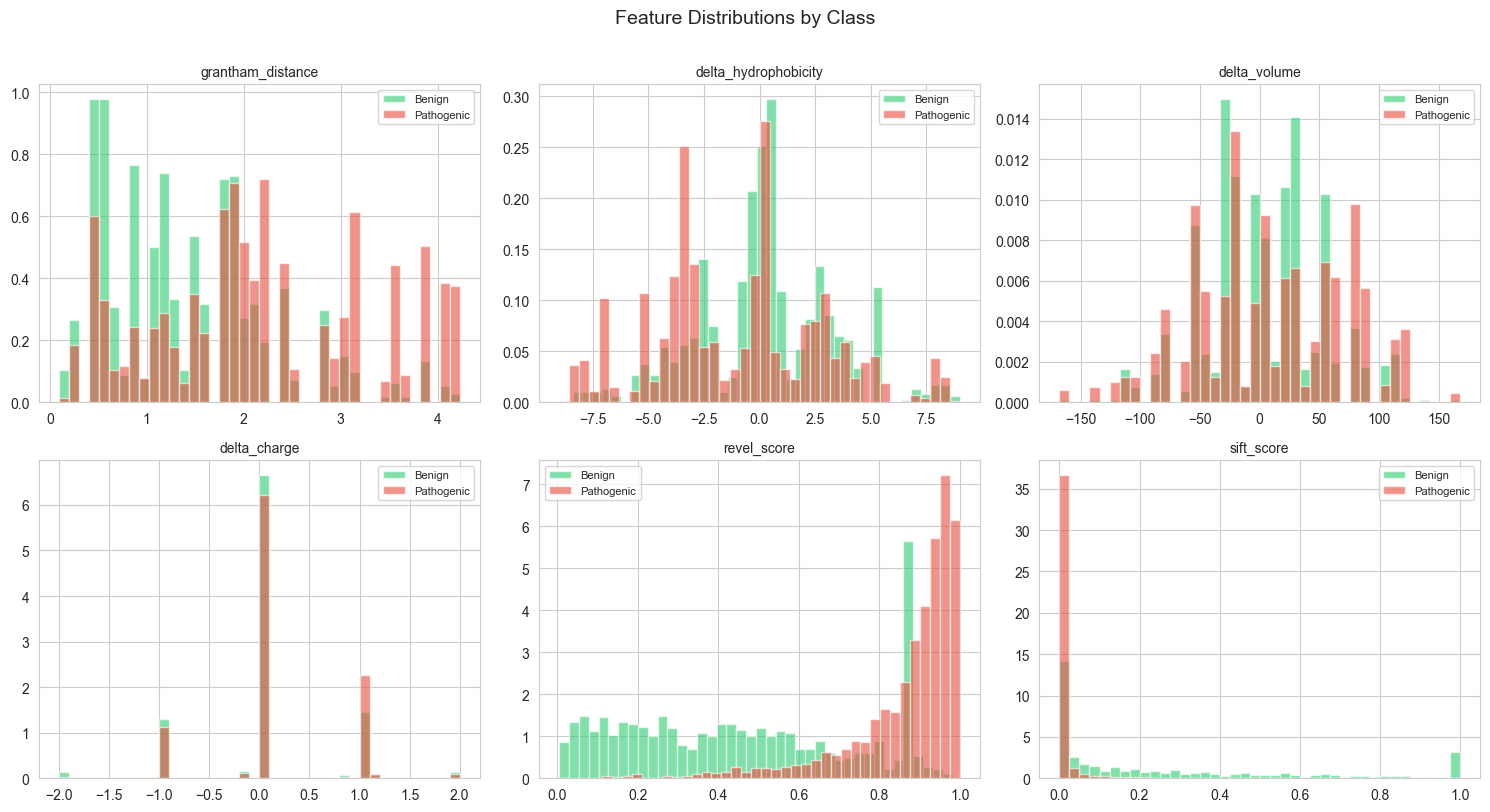

In [23]:
# ── Phase 4.2: Feature Distributions — Key Features by Class ─────────────────

# Select a subset of representative features for plotting
plot_features = [c for c in [
    "grantham_distance", "delta_hydrophobicity", "delta_volume", "delta_charge",
    "cadd_phred", "revel_score", "sift_score", "polyphen2_hdiv_score",
    "phylop100way_vertebrate", "gerp_rs",
    "gnomad_exomes_af", "max_population_af",
] if c in X_imputed.columns]

n_feat = len(plot_features)
if n_feat > 0:
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    plot_df = X_imputed.copy()
    plot_df["label"] = y

    for i, feat in enumerate(plot_features):
        ax = axes[i]
        for lab, color, name in [(0, "#2ecc71", "Benign"), (1, "#e74c3c", "Pathogenic")]:
            subset = plot_df[plot_df["label"] == lab][feat].dropna()
            ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, density=True)
        ax.set_title(feat, fontsize=10)
        ax.legend(fontsize=8)

    # Hide unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Feature Distributions by Class", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No plot features available — check column names after running the pipeline.")

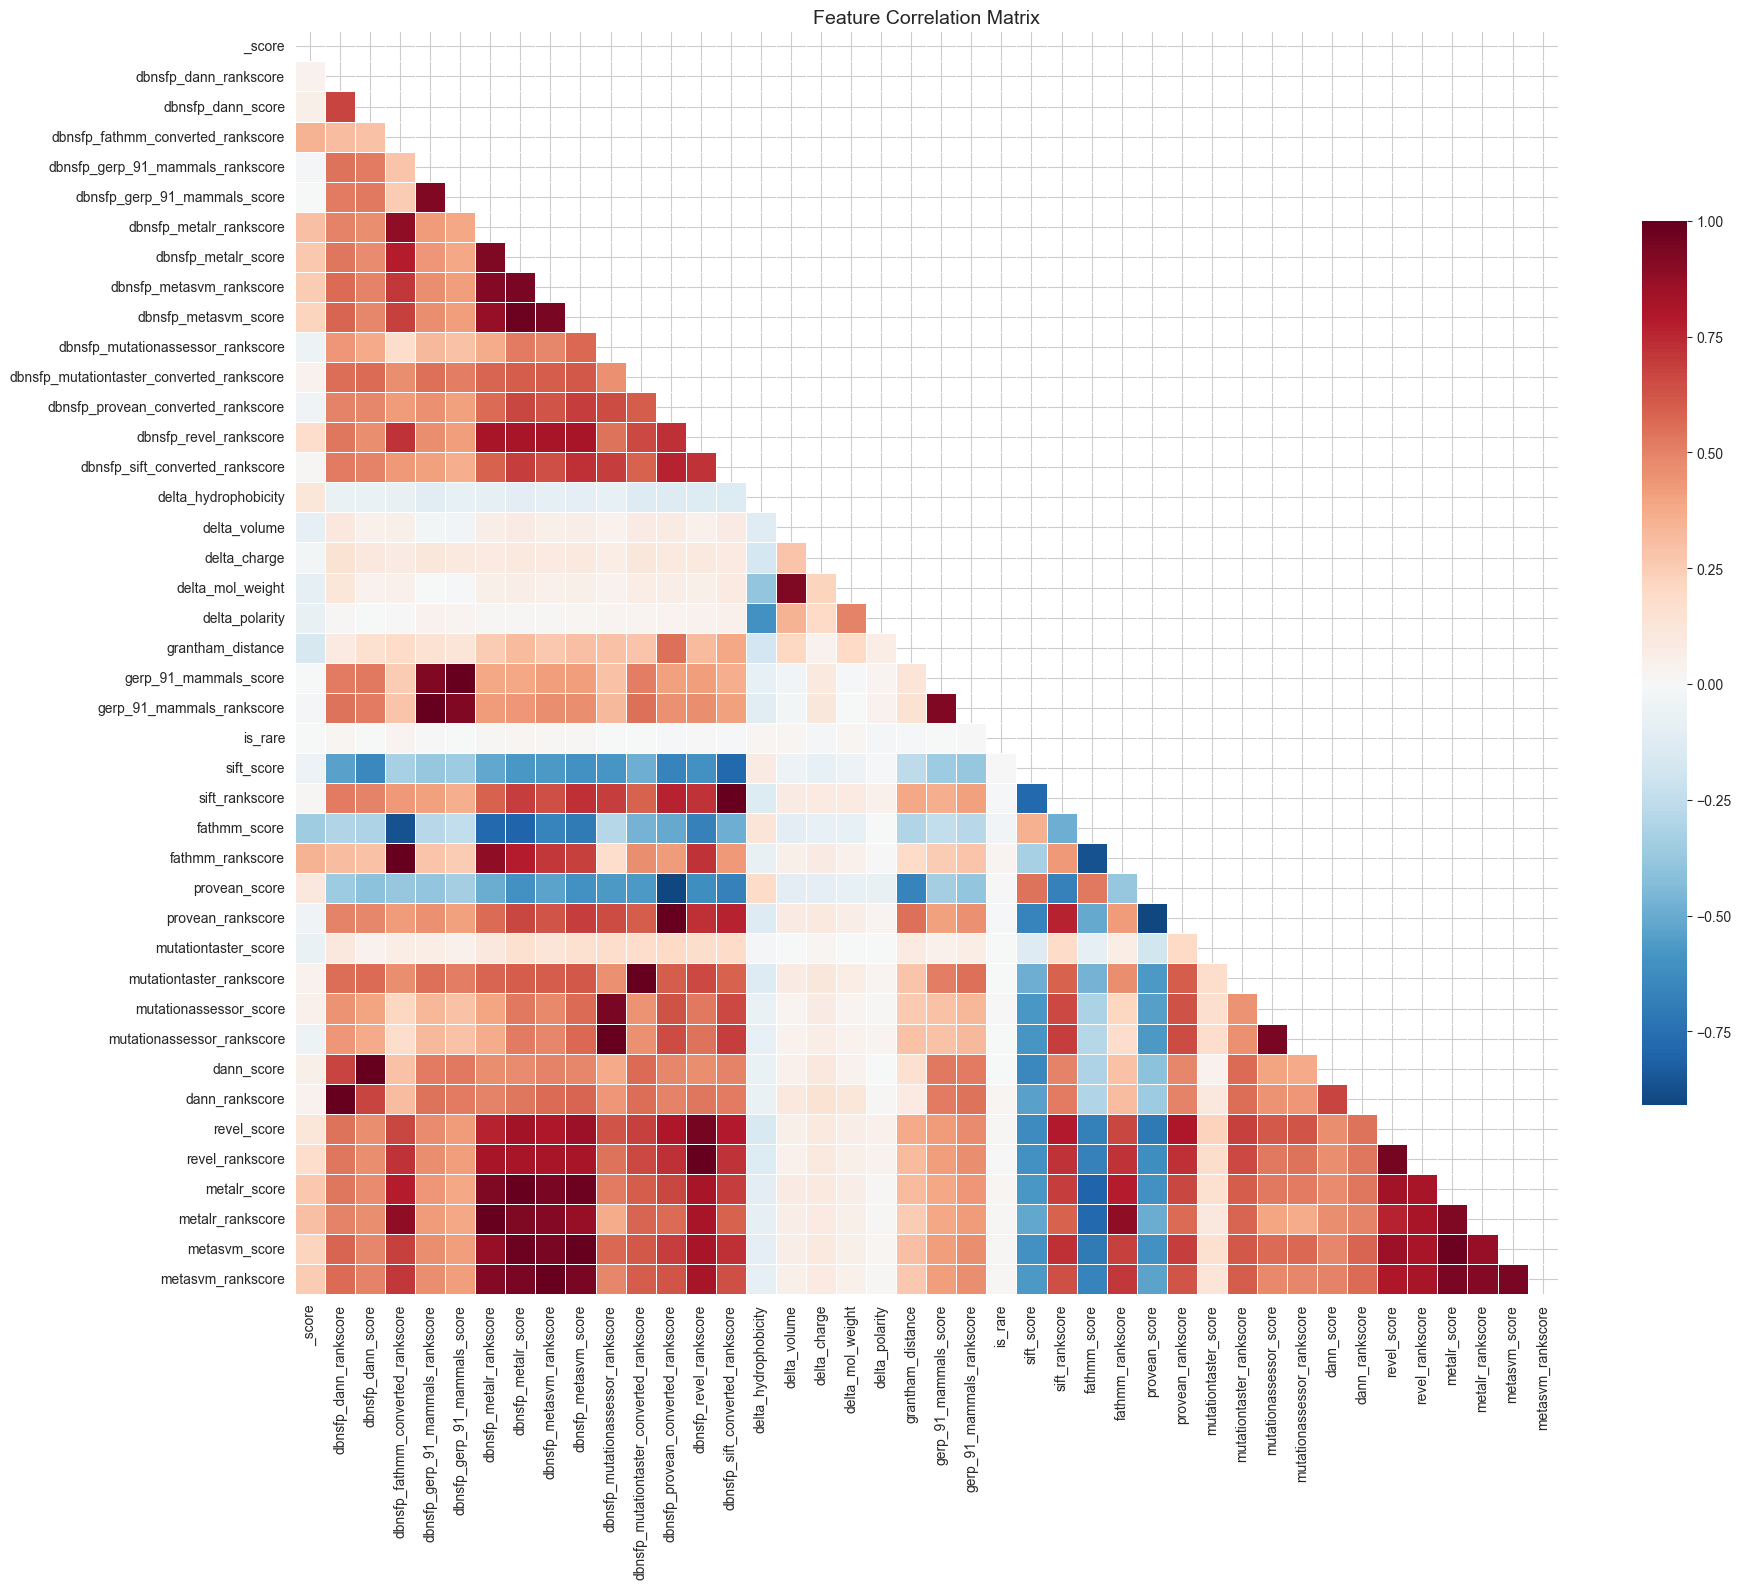


⚠️  Highly correlated feature pairs (|r| > 0.9):
  dbnsfp_dann_rankscore  ↔  dann_rankscore  (r = 1.000)
  dbnsfp_dann_score  ↔  dann_score  (r = 1.000)
  dbnsfp_fathmm_converted_rankscore  ↔  fathmm_rankscore  (r = 1.000)
  dbnsfp_gerp_91_mammals_rankscore  ↔  gerp_91_mammals_rankscore  (r = 1.000)
  dbnsfp_gerp_91_mammals_score  ↔  gerp_91_mammals_score  (r = 1.000)
  dbnsfp_metalr_rankscore  ↔  metalr_rankscore  (r = 1.000)
  dbnsfp_metalr_score  ↔  metalr_score  (r = 1.000)
  dbnsfp_metasvm_rankscore  ↔  metasvm_rankscore  (r = 1.000)
  dbnsfp_metasvm_score  ↔  metasvm_score  (r = 1.000)
  dbnsfp_mutationassessor_rankscore  ↔  mutationassessor_rankscore  (r = 1.000)
  dbnsfp_mutationtaster_converted_rankscore  ↔  mutationtaster_rankscore  (r = 1.000)
  dbnsfp_provean_converted_rankscore  ↔  provean_rankscore  (r = 1.000)
  dbnsfp_revel_rankscore  ↔  revel_rankscore  (r = 1.000)
  dbnsfp_sift_converted_rankscore  ↔  sift_rankscore  (r = 1.000)
  dbnsfp_metalr_score  ↔  dbnsfp_metas

In [24]:
# ── Phase 4.3: Correlation Heatmap ────────────────────────────────────────────

corr = X_imputed.corr()

# Plot — if many features, show only top correlated pairs
fig, ax = plt.subplots(figsize=(min(20, len(feature_cols)*0.5+2),
                                 min(16, len(feature_cols)*0.4+2)))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
            square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7},
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# Print highly correlated pairs (|r| > 0.9)
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.9:
            high_corr.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))
if high_corr:
    print(f"\n⚠️  Highly correlated feature pairs (|r| > 0.9):")
    for f1, f2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f"  {f1}  ↔  {f2}  (r = {r:.3f})")
else:
    print("No feature pairs with |r| > 0.9")

---
## Phase 5 — Model Training & Evaluation

### Strategy
1. **Train/Test Split** — 80/20, stratified
2. **Class Imbalance** — SMOTE on training set only
3. **Baseline Models** — Logistic Regression, Random Forest, XGBoost, LightGBM
4. **Hyperparameter Tuning** — GridSearchCV (5-fold stratified) on best 2 models
5. **Evaluation** — Accuracy, F1, AUC-ROC, MCC, Confusion Matrix, ROC Curve

In [25]:
# ── Phase 5.1: Train/Test Split & SMOTE ──────────────────────────────────────

SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape[0]:,} samples  |  Test: {X_test.shape[0]:,} samples")
print(f"Train class dist: Benign={sum(y_train==0):,}  Pathogenic={sum(y_train==1):,}")

# Scale features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)

# Apply SMOTE to training set only
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print(f"\nAfter SMOTE: {len(X_train_sm):,} samples  Benign={sum(y_train_sm==0):,}  Pathogenic={sum(y_train_sm==1):,}")

Train: 3,091 samples  |  Test: 773 samples
Train class dist: Benign=880  Pathogenic=2,211

After SMOTE: 4,422 samples  Benign=2,211  Pathogenic=2,211


  File "c:\Users\Umut\.conda\envs\ai\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Umut\.conda\envs\ai\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Umut\.conda\envs\ai\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Umut\.conda\envs\ai\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [26]:
# ── Phase 5.2: Train Baseline Models ─────────────────────────────────────────

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=SEED),
    "Random Forest":       RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "XGBoost":             XGBClassifier(n_estimators=300, use_label_encoder=False,
                                         eval_metric="logloss", random_state=SEED, verbosity=0),
    "LightGBM":            LGBMClassifier(n_estimators=300, random_state=SEED, verbose=-1),
}

results = {}

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train_sm, y_train_sm)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    mcc  = matthews_corrcoef(y_test, y_pred)

    results[name] = {
        "model": model, "y_pred": y_pred, "y_prob": y_prob,
        "Accuracy": acc, "F1": f1, "AUC-ROC": auc, "MCC": mcc,
    }
    print(f"  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}")

# Summary table
results_df = pd.DataFrame({k: {m: v for m, v in v.items() if m not in ["model", "y_pred", "y_prob"]}
                            for k, v in results.items()}).T.sort_values("F1", ascending=False)
print("\n" + "="*60)
print("BASELINE RESULTS")
print("="*60)
results_df

Training Logistic Regression ...
  Acc=0.8668  F1=0.9016  AUC=0.9474  MCC=0.7080
Training Random Forest ...
  Acc=0.9185  F1=0.9417  AUC=0.9670  MCC=0.8089
Training XGBoost ...
  Acc=0.9211  F1=0.9443  AUC=0.9723  MCC=0.8096
Training LightGBM ...
  Acc=0.9263  F1=0.9476  AUC=0.9748  MCC=0.8249

BASELINE RESULTS


,Accuracy,F1,AUC-ROC,MCC
LightGBM,0.926261,0.947562,0.974799,0.824936
XGBoost,0.921087,0.944292,0.972333,0.809564
Random Forest,0.918499,0.941721,0.966953,0.808866
Logistic Regression,0.866753,0.901624,0.947378,0.707957


In [27]:
# ── Phase 5.3: Hyperparameter Tuning — Top 2 Models ──────────────────────────

# Pick top 2 models by F1
top2 = results_df.index[:2].tolist()
print(f"Tuning: {top2}")

param_grids = {
    "Random Forest": {
        "n_estimators": [200, 400],
        "max_depth": [None, 20, 30],
        "min_samples_split": [2, 5],
    },
    "XGBoost": {
        "n_estimators": [200, 400],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.05, 0.1],
        "subsample": [0.8, 1.0],
    },
    "LightGBM": {
        "n_estimators": [200, 400],
        "max_depth": [-1, 15, 30],
        "learning_rate": [0.05, 0.1],
        "num_leaves": [31, 63],
    },
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "penalty": ["l2"],
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
tuned_results = {}

for name in top2:
    print(f"\n{'='*50}")
    print(f"Tuning {name} ...")
    base_model = models[name]
    grid = param_grids.get(name, {})
    if not grid:
        print(f"  No param grid defined — skipping")
        tuned_results[name] = results[name]
        continue

    search = GridSearchCV(base_model, grid, cv=cv, scoring="f1",
                          n_jobs=-1, verbose=0, refit=True)
    search.fit(X_train_sm, y_train_sm)

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)

    tuned_results[name] = {
        "model": best_model, "y_pred": y_pred, "y_prob": y_prob,
        "Accuracy": acc, "F1": f1, "AUC-ROC": auc, "MCC": mcc,
    }
    print(f"  Best params: {search.best_params_}")
    print(f"  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  MCC={mcc:.4f}")

# Merge tuned results into main results dict
for name, res in tuned_results.items():
    results[name + " (tuned)"] = res

Tuning: ['LightGBM', 'XGBoost']

Tuning LightGBM ...
  Best params: {'learning_rate': 0.1, 'max_depth': 15, 'n_estimators': 400, 'num_leaves': 63}
  Acc=0.9237  F1=0.9458  AUC=0.9748  MCC=0.8180

Tuning XGBoost ...
  Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.8}
  Acc=0.9263  F1=0.9479  AUC=0.9745  MCC=0.8221


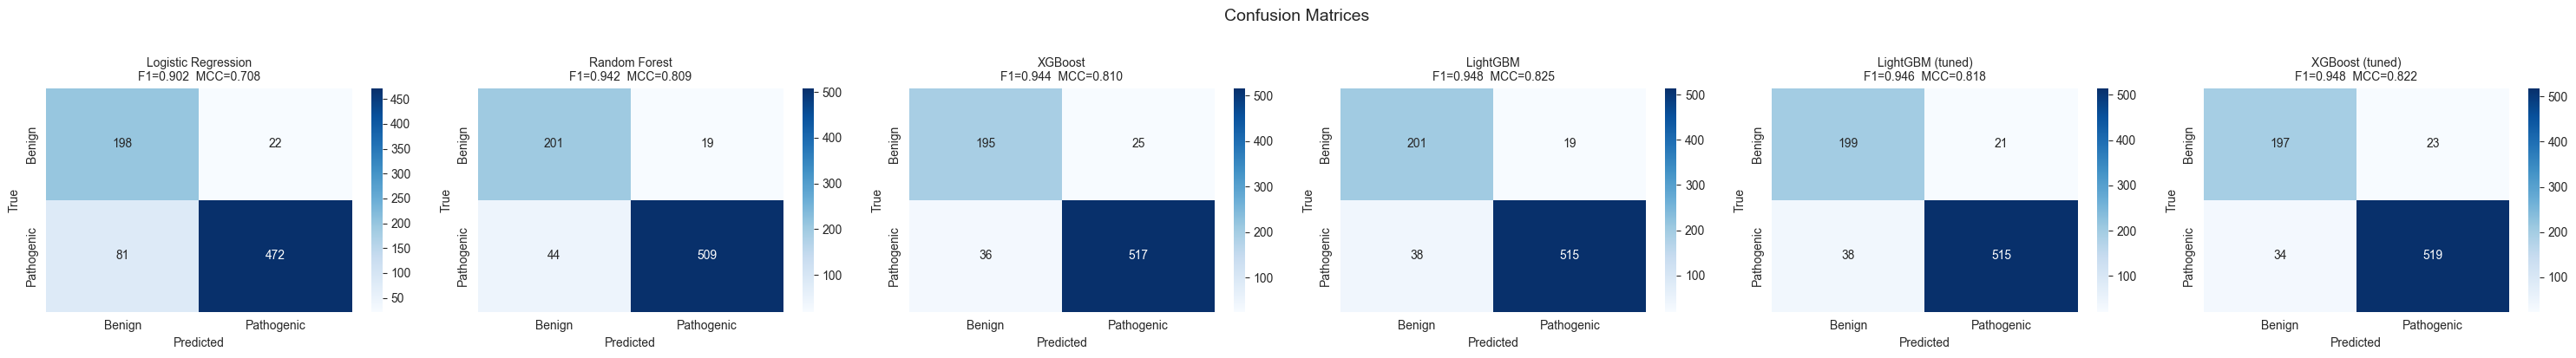

In [28]:
# ── Phase 5.4: Evaluation — Confusion Matrices ──────────────────────────────

eval_models = {k: v for k, v in results.items() if "y_pred" in v}
n_models = len(eval_models)

fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, eval_models.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Pathogenic"],
                yticklabels=["Benign", "Pathogenic"])
    ax.set_title(f"{name}\nF1={res['F1']:.3f}  MCC={res['MCC']:.3f}", fontsize=10)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

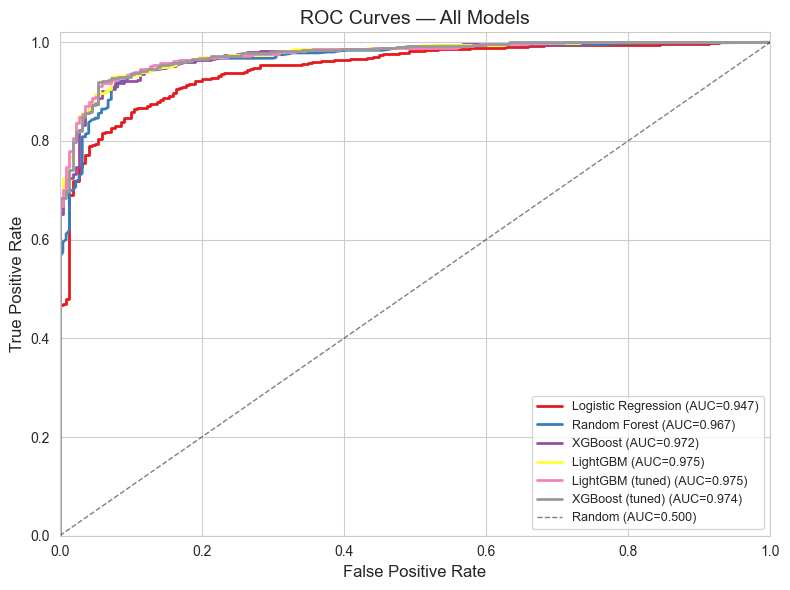

In [29]:
# ── Phase 5.5: ROC Curves ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = plt.cm.Set1(np.linspace(0, 1, len(eval_models)))

for (name, res), color in zip(eval_models.items(), colors_roc):
    if "y_prob" in res:
        fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
        ax.plot(fpr, tpr, label=f"{name} (AUC={res['AUC-ROC']:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random (AUC=0.500)")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

Best model: XGBoost (tuned)
  F1=0.9479  AUC=0.9745


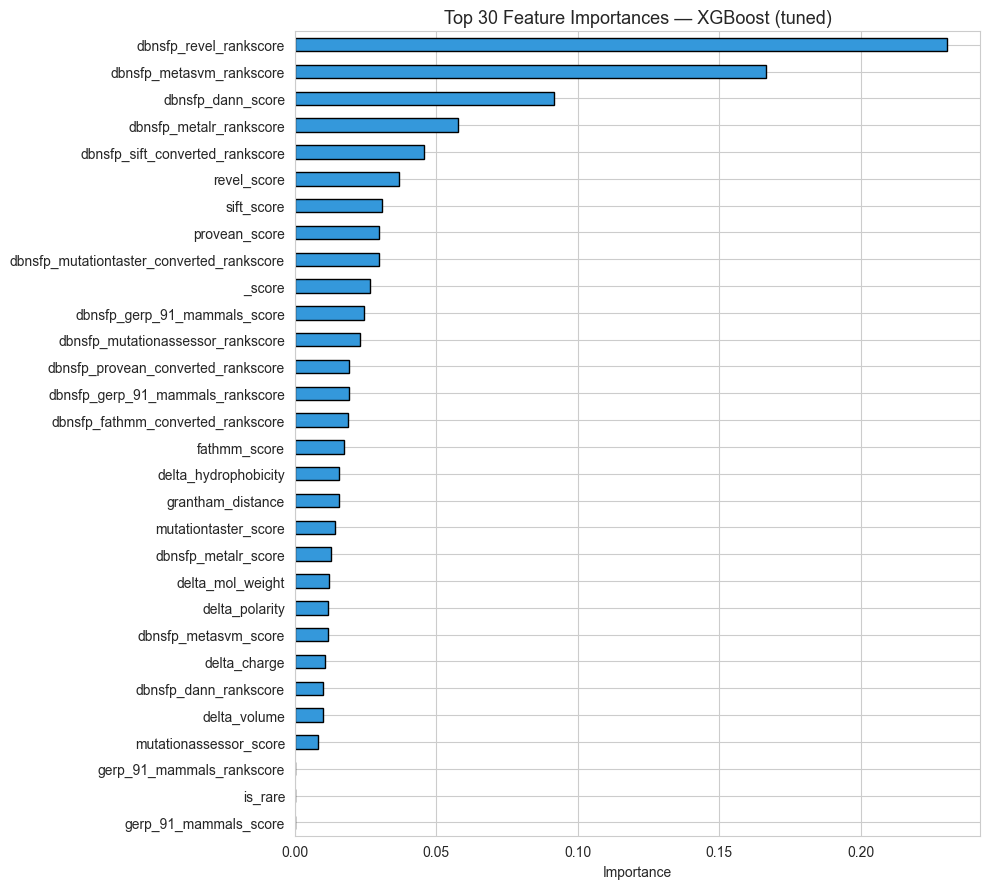


Top 10 features:
   1. dbnsfp_revel_rankscore: 0.2307
   2. dbnsfp_metasvm_rankscore: 0.1666
   3. dbnsfp_dann_score: 0.0917
   4. dbnsfp_metalr_rankscore: 0.0576
   5. dbnsfp_sift_converted_rankscore: 0.0456
   6. revel_score: 0.0368
   7. sift_score: 0.0309
   8. provean_score: 0.0296
   9. dbnsfp_mutationtaster_converted_rankscore: 0.0296
  10. _score: 0.0264


In [30]:
# ── Phase 5.6: Feature Importance (Best Model) ───────────────────────────────

# Pick best model by F1
best_name = max(eval_models, key=lambda k: eval_models[k]["F1"])
best_model = eval_models[best_name]["model"]
print(f"Best model: {best_name}")
print(f"  F1={eval_models[best_name]['F1']:.4f}  AUC={eval_models[best_name]['AUC-ROC']:.4f}")

# Extract feature importances
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=X_imputed.columns).sort_values(ascending=False)

    # Plot top 30
    top_n = min(30, len(feat_imp))
    fig, ax = plt.subplots(figsize=(10, max(6, top_n * 0.3)))
    feat_imp.head(top_n).sort_values().plot.barh(ax=ax, color="#3498db", edgecolor="black")
    ax.set_title(f"Top {top_n} Feature Importances — {best_name}", fontsize=13)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(f"\nTop 10 features:")
    for i, (fname, imp) in enumerate(feat_imp.head(10).items(), 1):
        print(f"  {i:2d}. {fname}: {imp:.4f}")
else:
    print("Feature importances not available for this model type.")

In [31]:
# ── Phase 5.7: Classification Report (Best Model) ────────────────────────────

print(f"Classification Report — {best_name}")
print("="*60)
print(classification_report(y_test, eval_models[best_name]["y_pred"],
                            target_names=["Benign", "Pathogenic"]))

Classification Report — XGBoost (tuned)
              precision    recall  f1-score   support

      Benign       0.85      0.90      0.87       220
  Pathogenic       0.96      0.94      0.95       553

    accuracy                           0.93       773
   macro avg       0.91      0.92      0.91       773
weighted avg       0.93      0.93      0.93       773



---
## Phase 6 — Finalization
Save the best model and preprocessing artifacts for reproducibility.

In [ ]:
# ── Phase 6: Save Best Model & Summary ────────────────────────────────────────
import pickle

# Save model
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save feature list
with open("feature_columns.json", "w") as f:
    json.dump(X_imputed.columns.tolist(), f, indent=2)

# Print final summary
print("="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"Best model        : {best_name}")
print(f"Number of features: {X_imputed.shape[1]}")
print(f"Training samples  : {len(X_train_sm):,} (after SMOTE)")
print(f"Test samples      : {len(X_test):,}")
print(f"Accuracy          : {eval_models[best_name]['Accuracy']:.4f}")
print(f"F1 Score          : {eval_models[best_name]['F1']:.4f}")
print(f"AUC-ROC           : {eval_models[best_name]['AUC-ROC']:.4f}")
print(f"MCC               : {eval_models[best_name]['MCC']:.4f}")
print(f"\nSaved: best_model.pkl, scaler.pkl, feature_columns.json")
print("="*60)

FINAL SUMMARY
Best model        : XGBoost (tuned)
Number of features: 42
Training samples  : 4,422 (after SMOTE)
Test samples      : 773
Accuracy          : 0.9263
F1 Score          : 0.9479
AUC-ROC           : 0.9745
MCC               : 0.8221

Saved: best_model.pkl, scaler.pkl, feature_columns.json


: 